In [23]:
from ddgs import DDGS
from fastcore.all import *
from fastdownload import download_url
from fastai.vision.all import *

In [24]:
path = Path('me or not')

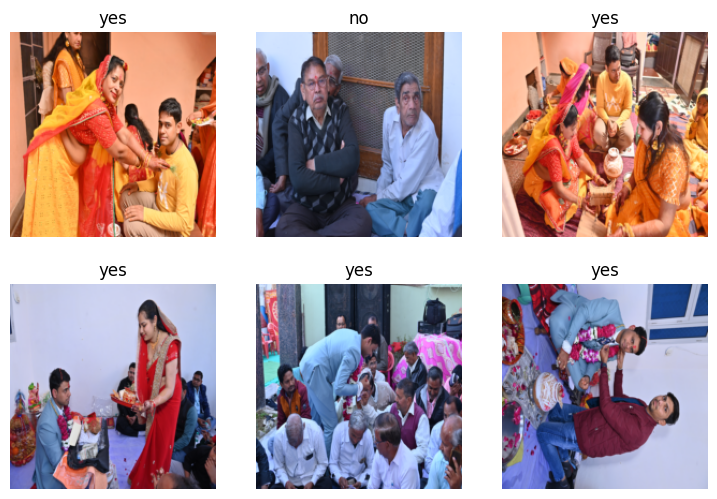

In [25]:
dls = DataBlock(
    blocks = (ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct=0.2, seed=42),
    get_y = parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=8)

dls.show_batch(max_n=6)

In [26]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.101638,0.210135,0.080000,01:07


epoch,train_loss,valid_loss,error_rate,time
0,0.585669,0.131147,0.000000,01:08
1,0.442477,0.216719,0.080000,01:53
2,0.519362,0.100622,0.000000,01:19


In [28]:
is_me, _, probs = learn.predict(PILImage.create('no.JPG'))
# predict
# f'{predict[2][0]:.4f}'
print(f'Is that me: {is_me} with probability {probs[0]:.4f}')

Is that me: no with probability 0.9856
